<a href="https://colab.research.google.com/github/ekuelkpodar/Complex-Systems-Google-Colab-Experiment/blob/main/Multi_drone_task_allocation_as_a_hypergraph_matching_problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Drone Task Allocation via Spectral Hypergraph Partitioning

This notebook models a heterogeneous drone fleet and mission tasks as a hypergraph problem. We will:
1. Model drones (nodes) and tasks (hyperedges).
2. Apply spectral partitioning to allocate task bundles.
3. Minimize communication overhead while maximizing coverage.

In [3]:
!pip install hypernetx matplotlib numpy scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.4/591.4 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 69.6 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [ ]:
import numpy as np
import hypernetx as hnx
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh
from sklearn.cluster import KMeans

# Define heterogeneous drones (nodes)
# Types: S (Sensor), K (Striker), R (Relay)
drones = {
    'd1': 'Sensor', 'd2': 'Sensor',
    'd3': 'Striker', 'd4': 'Striker',
    'd5': 'Relay', 'd6': 'Relay'
}

# Define mission tasks (hyperedges) based on joint-capability requirements
# Task 1 needs Sensors and Strikers
# Task 2 needs Strikers and Relays
# Task 3 needs all types
scenes = {
    'T1': ('d1', 'd2', 'd3'),
    'T2': ('d3', 'd4', 'd5'),
    'T3': ('d1', 'd4', 'd6'),
    'T4': ('d2', 'd5', 'd6')
}

H = hnx.Hypergraph(scenes)

plt.figure(figsize=(8, 6))
hnx.draw(H)
plt.title("Hypergraph of Drone-Task Requirements")
plt.show()

In [1]:
import numpy as np
import hypernetx as hnx
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh
from sklearn.cluster import KMeans

# Drone fleet and task definitions
drones = {
    'd1': 'Sensor', 'd2': 'Sensor',
    'd3': 'Striker', 'd4': 'Striker',
    'd5': 'Relay', 'd6': 'Relay'
}

scenes = {
    'T1': ('d1', 'd2', 'd3'),
    'T2': ('d3', 'd4', 'd5'),
    'T3': ('d1', 'd4', 'd6'),
    'T4': ('d2', 'd5', 'd6')
}

H = hnx.Hypergraph(scenes)

# 1. Construct the Incident Matrix
H_matrix = H.incidence_matrix().toarray()

# 2. Compute Degree Matrices
D_v = np.diag(np.sum(H_matrix, axis=1))
D_e = np.diag(np.sum(H_matrix, axis=0))

# 3. Compute the Hypergraph Laplacian (Zhou et al. approach)
inv_D_e = np.linalg.inv(D_e)
L = D_v - H_matrix @ inv_D_e @ H_matrix.T

# 4. Spectral Partitioning via Fiedler Vector
vals, vecs = eigsh(L, k=2, which='SM')
fiedler_vector = vecs[:, 1]
# Fixed: changed n_components to n_clusters
clusters = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(fiedler_vector.reshape(-1, 1))

# Results Mapping
drone_ids = list(H.nodes)
allocation = {drone_ids[i]: f'Team {clusters[i]}' for i in range(len(drone_ids))}

print('Optimal Drone Team Allocation:')
for drone, team in allocation.items():
    print(f'{drone} ({drones[drone]}): {team}')

print('\nTask Connectivity Analysis:')
for task_id, members in scenes.items():
    teams = set(allocation[m] for m in members)
    status = 'Internal (Optimal)' if len(teams) == 1 else 'Cross-team (Overhead Required)'
    print(f'{task_id}: {status}')

Optimal Drone Team Allocation:
d1 (Sensor): Team 0
d2 (Sensor): Team 0
d3 (Striker): Team 0
d4 (Striker): Team 1
d5 (Relay): Team 1
d6 (Relay): Team 1

Task Connectivity Analysis:
T1: Internal (Optimal)
T2: Cross-team (Overhead Required)
T3: Cross-team (Overhead Required)
T4: Cross-team (Overhead Required)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


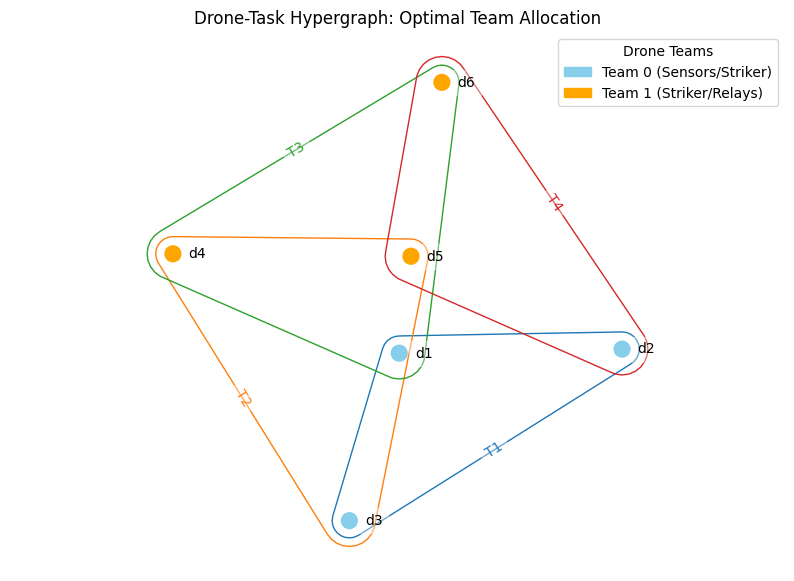

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [1]:
!pip install hypernetx
import numpy as np
import hypernetx as hnx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.sparse.linalg import eigsh
from sklearn.cluster import KMeans

# 1. Re-define the Drone-Task Hypergraph
drones = {'d1': 'S', 'd2': 'S', 'd3': 'K', 'd4': 'K', 'd5': 'R', 'd6': 'R'}
scenes = {
    'T1': ('d1', 'd2', 'd3'),
    'T2': ('d3', 'd4', 'd5'),
    'T3': ('d1', 'd4', 'd6'),
    'T4': ('d2', 'd5', 'd6')
}
H = hnx.Hypergraph(scenes)

# 2. Spectral Partitioning Logic
H_matrix = H.incidence_matrix().toarray()
D_v = np.diag(np.sum(H_matrix, axis=1))
D_e = np.diag(np.sum(H_matrix, axis=0))
inv_D_e = np.linalg.inv(D_e)
L = D_v - H_matrix @ inv_D_e @ H_matrix.T
vals, vecs = eigsh(L, k=2, which='SM')
fiedler_vector = vecs[:, 1]
clusters = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(fiedler_vector.reshape(-1, 1))

# 3. Visualization with defined color mapping
color_map = {0: 'skyblue', 1: 'orange'}
node_list = list(H.nodes)
ordered_colors = [color_map[clusters[i]] for i in range(len(node_list))]

plt.figure(figsize=(10, 7))
hnx.draw(H,
         nodes_kwargs={'facecolors': ordered_colors},
         node_radius=1.5)

# Legend for clarity
team0_patch = mpatches.Patch(color='skyblue', label='Team 0 (Sensors/Striker)')
team1_patch = mpatches.Patch(color='orange', label='Team 1 (Striker/Relays)')
plt.legend(handles=[team0_patch, team1_patch], title="Drone Teams", loc='upper right')

plt.title("Drone-Task Hypergraph: Optimal Team Allocation")
plt.show()